In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pickle
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, classification_report
)

import xgboost as xgb
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
df = pd.read_csv("data.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (188866, 30)

Columns:
['Branch', 'FacilityAmount', 'Granted Date', 'Tenor', 'Effective Rate', 'FlatRate', 'Type of Rental Paid', 'SchemeType', 'Prepayment', 'NetRental', 'DownPayment', 'No of Rental in arrears', 'Age', 'ArrearsCapital', 'ArrearsInterest', 'ArrearsVat', 'ArrearsOD', 'ArrearsOther', 'ArrearsInsu', 'ArrearsSundry', 'Advance', 'AdvanceRental', 'AdvanceSundry', 'AdvanceOther', 'Equipment Type', 'Status', 'Last Receipt Paid Amount', 'NET-OUTSTANDING', 'ArrearsInsuEasyPay', 'arrears_intensity']

First 5 rows:


,Branch,FacilityAmount,Granted Date,Tenor,Effective Rate,FlatRate,Type of Rental Paid,SchemeType,Prepayment,NetRental,...,Advance,AdvanceRental,AdvanceSundry,AdvanceOther,Equipment Type,Status,Last Receipt Paid Amount,NET-OUTSTANDING,ArrearsInsuEasyPay,arrears_intensity
0,GODAGAMA,288330.0,4/9/2018,36,25.0,20.06,MONTHLY,NORMAL,0,12828.0,...,0.0,0.0,0,0,MOTOR CYCLES,Early Settlement Completed,53241.0,0.0,0.0,0.0
1,GODAGAMA,311430.0,4/9/2018,36,25.0,20.33,MONTHLY,NORMAL,0,13927.0,...,0.0,0.0,0,0,MOTOR CYCLES,Write Off,196000.0,0.0,0.0,0.0
2,GODAGAMA,2200000.0,4/9/2018,60,20.0,12.43,MONTHLY,NORMAL,0,59459.0,...,0.0,0.0,0,0,MOTOR CARS,Early Settlement Completed,2185000.0,0.0,0.0,0.0
3,GODAGAMA,232330.0,4/10/2018,48,25.0,19.95,MONTHLY,NORMAL,0,8703.0,...,0.0,0.0,0,0,MOTOR CYCLES,Normal Settlement Completed,40010.0,0.0,0.0,0.0
4,GODAGAMA,187530.0,4/10/2018,36,25.0,21.02,MONTHLY,NORMAL,0,8494.0,...,0.0,0.0,0,0,MOTOR CYCLES,Early Settlement Completed,26415.0,0.0,0.0,0.0


In [3]:
features = [
    'FacilityAmount',
    'Tenor',
    'Effective Rate',
    'FlatRate',
    'NetRental',
    'DownPayment',
    'No of Rental in arrears',
    'Age',
    'ArrearsCapital',
    'ArrearsInterest',
    'ArrearsVat',
    'ArrearsOD',
    'ArrearsOther',
    'ArrearsInsu',
    'ArrearsSundry',
    'Advance',
    'AdvanceRental',
    'AdvanceSundry',
    'AdvanceOther',
    'Last Receipt Paid Amount',
    'NET-OUTSTANDING',
    'ArrearsInsuEasyPay',
    'arrears_intensity'
]

data = df[features].copy()

# Fill any missing values with 0
data = data.fillna(0)

print(f"Feature matrix shape: {data.shape}")
print(f"\nFeature list ({len(features)} features):")
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")
print(f"\nMissing values: {data.isnull().sum().sum()}")

Feature matrix shape: (188866, 23)

Feature list (23 features):
   1. FacilityAmount
   2. Tenor
   3. Effective Rate
   4. FlatRate
   5. NetRental
   6. DownPayment
   7. No of Rental in arrears
   8. Age
   9. ArrearsCapital
  10. ArrearsInterest
  11. ArrearsVat
  12. ArrearsOD
  13. ArrearsOther
  14. ArrearsInsu
  15. ArrearsSundry
  16. Advance
  17. AdvanceRental
  18. AdvanceSundry
  19. AdvanceOther
  20. Last Receipt Paid Amount
  21. NET-OUTSTANDING
  22. ArrearsInsuEasyPay
  23. arrears_intensity

Missing values: 0


In [4]:
# Show original status categories
print("Original Status distribution:")
print(df['Status'].value_counts())

# Convert text status to binary
default_categories = ['Write Off', 'REPOSSESSION AND SOLD']
y = df['Status'].apply(lambda x: 1 if x in default_categories else 0)

X = data

print(f"\n--- After Binary Conversion ---")
print(f"Features (X) shape: {X.shape}")
print(f"Target  (y) shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nDefault rate: {y.mean():.4f}")

Original Status distribution:
Status
Early Settlement Completed     84199
Current Running                49473
Normal Settlement Completed    35810
Write Off                      17841
REPOSSESSION AND SOLD            980
Rescheduled                      523
Initiated / Not Activated         30
Activated / Not Printed           10
Name: count, dtype: int64

--- After Binary Conversion ---
Features (X) shape: (188866, 23)
Target  (y) shape: (188866,)

Target distribution:
Status
0    170045
1     18821
Name: count, dtype: int64

Default rate: 0.0997


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing  set: {X_test.shape[0]} samples")
print(f"\nTraining target distribution:\n{y_train.value_counts()}")
print(f"\nTesting target distribution:\n{y_test.value_counts()}")

Training set: 151092 samples
Testing  set: 37774 samples

Training target distribution:
Status
0    135962
1     15130
Name: count, dtype: int64

Testing target distribution:
Status
0    34083
1     3691
Name: count, dtype: int64


In [6]:
# Load pretrained models
cat_model_pretrained = joblib.load("catboost_default_risk_model.pkl")
print(f"CatBoost loaded: {type(cat_model_pretrained).__name__}")
print(f"  Expected features: {cat_model_pretrained.feature_names_}")

rf_model_dict = joblib.load("randomforest_model.pkl")
rf_model_pretrained = rf_model_dict['model']  # Extract model from dict
print(f"\nRandom Forest loaded: {type(rf_model_pretrained).__name__}")
print(f"  Expected features: {rf_model_dict['feature_columns']}")

xgb_model_pretrained = joblib.load("xgboost_default_model.pkl")
print(f"\nXGBoost loaded: {type(xgb_model_pretrained).__name__}")
print(f"  Expected features: {xgb_model_pretrained.get_booster().feature_names}")

print("\n" + "="*60)
print("NOTE: Pretrained models use different feature sets.")
print("Fresh models will be trained for the stacking ensemble.")
print("="*60)

CatBoost loaded: CatBoostClassifier
  Expected features: ['FacilityAmount', 'Tenor', 'Effective Rate', 'FlatRate', 'NetRental', 'DownPayment', 'No of Rental in arrears', 'Age', 'ArrearsCapital', 'ArrearsInterest', 'ArrearsVat', 'ArrearsOD', 'ArrearsOther', 'ArrearsInsu', 'ArrearsSundry', 'Advance', 'AdvanceRental', 'AdvanceSundry', 'AdvanceOther', 'Last Receipt Paid Amount', 'NET-OUTSTANDING', 'ArrearsInsuEasyPay', 'arrears_intensity', 'arrears_ratio', 'loan_age_ratio']

Random Forest loaded: RandomForestClassifier
  Expected features: ['FacilityAmount', 'Tenor', 'Effective Rate', 'FlatRate', 'NetRental', 'DownPayment', 'Age', 'No of Rental in arrears', 'ArrearsCapital', 'ArrearsInterest', 'ArrearsVat', 'ArrearsOD', 'arrears_intensity', 'debt_to_income_ratio', 'payment_coverage', 'arrears_ratio', 'overdue_intensity', 'payment_regularity', 'has_arrears', 'high_interest_flag', 'early_settlement', 'equipment_risk_score', 'branch_encoded', 'scheme_encoded', 'loan_age', 'tenor_to_age_ratio'

In [7]:
# Train fresh CatBoost
print("Training CatBoost...")
cat_model = CatBoostClassifier(
    iterations=500, depth=6, learning_rate=0.1,
    random_seed=42, verbose=100
)
cat_model.fit(X_train, y_train)
print("CatBoost trained.\n")

# Train fresh Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Random Forest trained.\n")

# Train fresh XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, verbosity=0, use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
print("XGBoost trained.\n")

print("All base models trained successfully on the 23-feature set.")

Training CatBoost...
0:	learn: 0.4156799	total: 299ms	remaining: 2m 29s
100:	learn: 0.0113711	total: 4.06s	remaining: 16.1s
200:	learn: 0.0094589	total: 7.26s	remaining: 10.8s
300:	learn: 0.0090559	total: 10s	remaining: 6.63s
400:	learn: 0.0084600	total: 13s	remaining: 3.2s
499:	learn: 0.0078353	total: 16s	remaining: 0us
CatBoost trained.

Training Random Forest...
Random Forest trained.

Training XGBoost...
XGBoost trained.

All base models trained successfully on the 23-feature set.


In [8]:
# Get prediction probabilities (probability of class 1 = Default)
cat_pred = cat_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict_proba(X_test)[:, 1]

print("Base Model Prediction Probabilities (first 10 samples):")
print(f"{'CatBoost':>12s} {'RandomForest':>14s} {'XGBoost':>10s}")
print("-" * 40)
for i in range(10):
    print(f"{cat_pred[i]:12.4f} {rf_pred[i]:14.4f} {xgb_pred[i]:10.4f}")

print(f"\nCatBoost     mean PD: {cat_pred.mean():.4f}")
print(f"RandomForest mean PD: {rf_pred.mean():.4f}")
print(f"XGBoost      mean PD: {xgb_pred.mean():.4f}")

Base Model Prediction Probabilities (first 10 samples):
    CatBoost   RandomForest    XGBoost
----------------------------------------
      0.9994         0.9252     0.9999
      0.0000         0.0034     0.0000
      0.0000         0.0006     0.0001
      0.0000         0.0023     0.0000
      0.0000         0.0012     0.0000
      0.0000         0.0012     0.0000
      0.0010         0.0038     0.0001
      0.0000         0.0016     0.0000
      1.0000         0.9764     1.0000
      0.0000         0.0008     0.0000

CatBoost     mean PD: 0.0975
RandomForest mean PD: 0.0976
XGBoost      mean PD: 0.0976


In [9]:
# Define base estimators for stacking
estimators = [
    ('catboost', CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.1,
        random_seed=42, verbose=0
    )),
    ('random_forest', RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    )),
    ('xgboost', xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, verbosity=0, use_label_encoder=False,
        eval_metric='logloss'
    ))
]

# Build the Stacking Classifier with Logistic Regression as the meta-learner
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    stack_method='predict_proba',
    passthrough=False
)

# Train the stacking model
print("Training Stacking Ensemble Model (5-fold CV)...")
print("This may take several minutes...\n")
stacking_model.fit(X_train, y_train)
print("\nStacking Ensemble Model training completed.")

# Save the stacking model
joblib.dump(stacking_model, "stacking_default_risk_model.pkl")
print("Stacking model saved as 'stacking_default_risk_model.pkl'")

Training Stacking Ensemble Model (5-fold CV)...
This may take several minutes...


Stacking Ensemble Model training completed.
Stacking model saved as 'stacking_default_risk_model.pkl'


In [10]:
# Generate predictions for all models
models = {
    'CatBoost': cat_model,
    'RandomForest': rf_model,
    'XGBoost': xgb_model,
    'Stacking Ensemble': stacking_model
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': roc
    })

# Display comparison table
results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')

print("=" * 75)
print("MODEL EVALUATION COMPARISON")
print("=" * 75)
print(results_df.round(4).to_string())
print("=" * 75)

# Highlight best model per metric
print("\nBest model per metric:")
for col in results_df.columns:
    best = results_df[col].idxmax()
    print(f"  {col:12s}: {best} ({results_df.loc[best, col]:.4f})")

MODEL EVALUATION COMPARISON
                   Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                            
CatBoost             0.9955     0.9914  0.9626    0.9768   0.9996
RandomForest         0.9953     0.9994  0.9526    0.9754   0.9994
XGBoost              0.9954     0.9911  0.9618    0.9762   0.9995
Stacking Ensemble    0.9956     0.9889  0.9661    0.9774   0.9995

Best model per metric:
  Accuracy    : Stacking Ensemble (0.9956)
  Precision   : RandomForest (0.9994)
  Recall      : Stacking Ensemble (0.9661)
  F1 Score    : Stacking Ensemble (0.9774)
  ROC AUC     : CatBoost (0.9996)


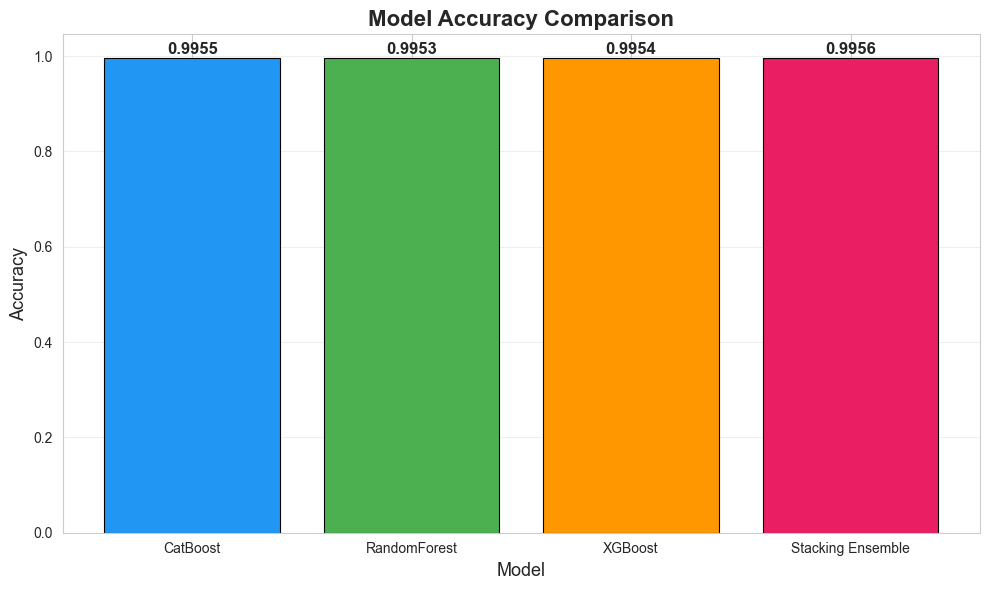

Accuracy comparison chart saved.


In [11]:
model_names = results_df.index.tolist()
accuracies = results_df['Accuracy'].values

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
        f'{acc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12
    )

ax.set_title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13)
ax.set_xlabel('Model', fontsize=13)
ax.set_ylim(0, max(accuracies) + 0.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Accuracy comparison chart saved.")

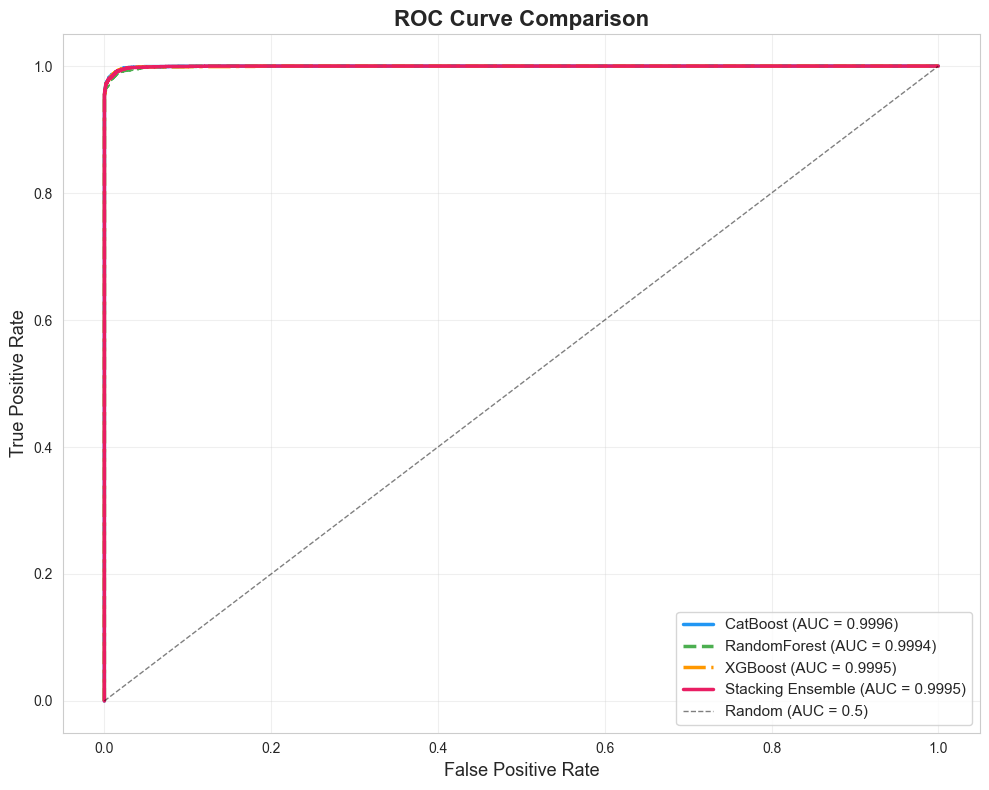

ROC curve comparison saved.


In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

line_styles = ['-', '--', '-.', '-']
colors_roc = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for (name, model), ls, color in zip(models.items(), line_styles, colors_roc):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, linestyle=ls, color=color, linewidth=2.5,
            label=f'{name} (AUC = {roc_auc_val:.4f})')

# Diagonal reference line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')

ax.set_title('ROC Curve Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve comparison saved.")

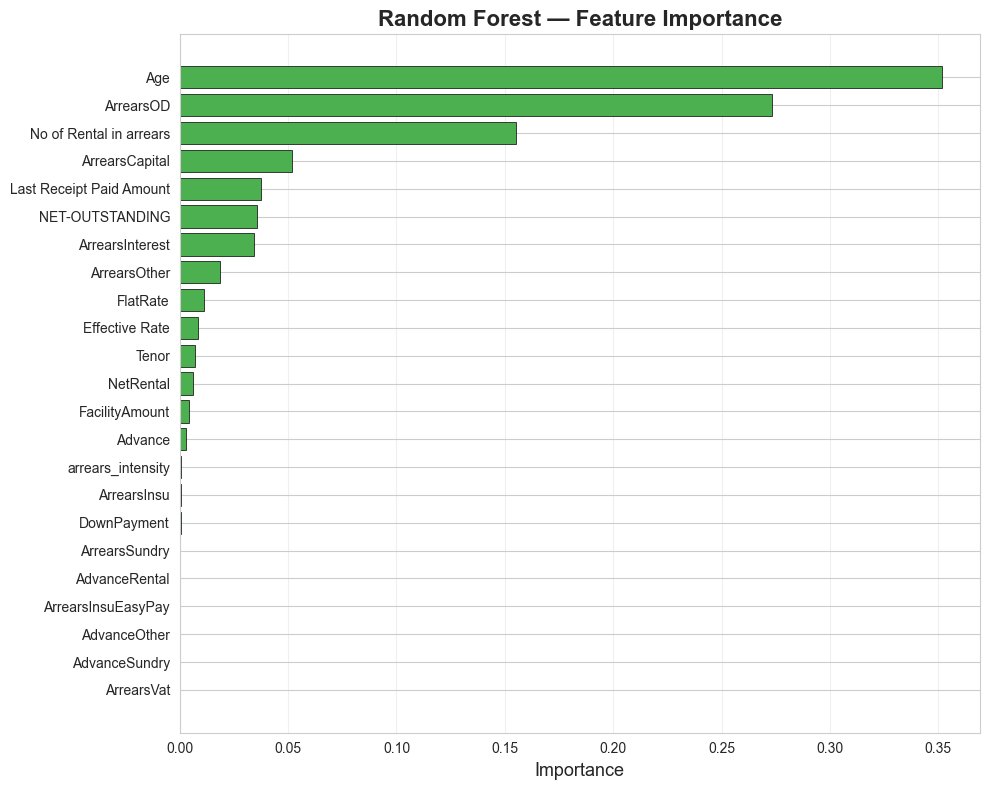

Random Forest feature importance saved.


In [13]:
# --- Random Forest Feature Importance ---
rf_importances = rf_model.feature_importances_
rf_feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': rf_importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(rf_feat_imp['Feature'], rf_feat_imp['Importance'], color='#4CAF50', edgecolor='black', linewidth=0.5)
ax.set_title('Random Forest \u2014 Feature Importance', fontsize=16, fontweight='bold')
ax.set_xlabel('Importance', fontsize=13)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Random Forest feature importance saved.")

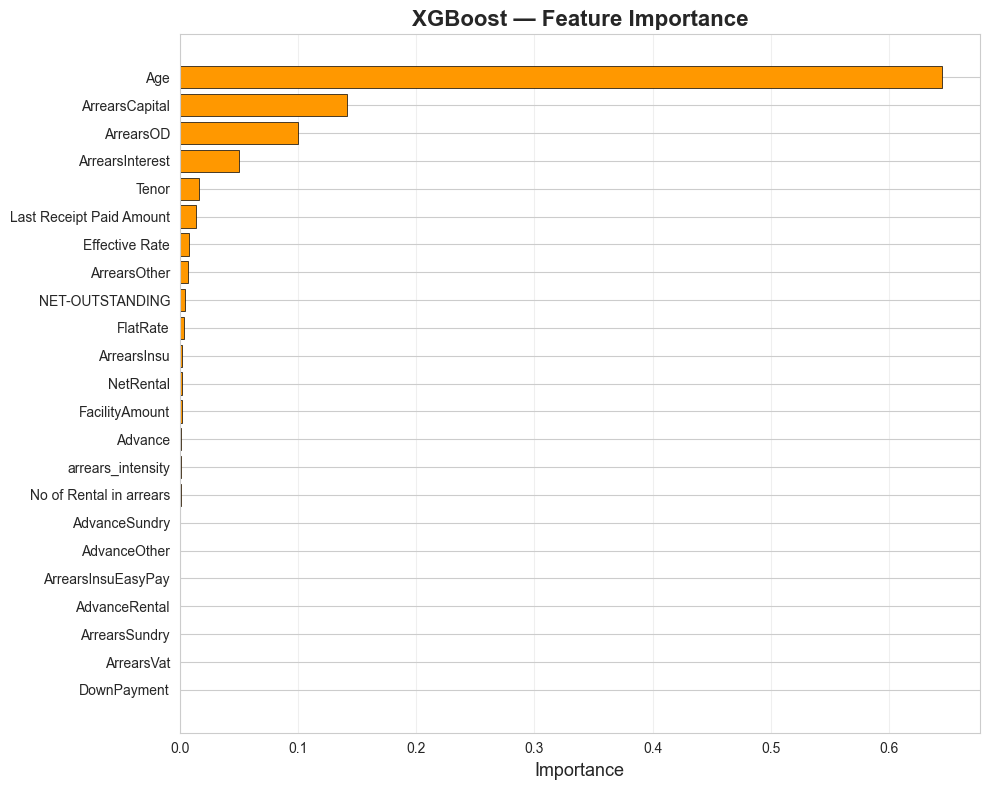

XGBoost feature importance saved.


In [14]:
# --- XGBoost Feature Importance ---
xgb_importances = xgb_model.feature_importances_
xgb_feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(xgb_feat_imp['Feature'], xgb_feat_imp['Importance'], color='#FF9800', edgecolor='black', linewidth=0.5)
ax.set_title('XGBoost \u2014 Feature Importance', fontsize=16, fontweight='bold')
ax.set_xlabel('Importance', fontsize=13)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("XGBoost feature importance saved.")

In [15]:
# Generate PD for the entire dataset using the stacking ensemble
pd_scores = stacking_model.predict_proba(X)[:, 1]

# Classify risk based on PD
def classify_risk(pd_value):
    if pd_value >= 0.80:
        return "High Risk"
    elif pd_value >= 0.20:
        return "Medium Risk"
    else:
        return "Low Risk"

df["Risk_Category"] = [classify_risk(p) for p in pd_scores]

print("Risk Category Distribution:")
print(df["Risk_Category"].value_counts())
print(f"\nSample output:")
print(df[["Status", "Risk_Category"]].head(20))

Risk Category Distribution:
Risk_Category
Low Risk       170089
High Risk       18188
Medium Risk       589
Name: count, dtype: int64

Sample output:
                         Status Risk_Category
0    Early Settlement Completed      Low Risk
1                     Write Off     High Risk
2    Early Settlement Completed      Low Risk
3   Normal Settlement Completed      Low Risk
4    Early Settlement Completed      Low Risk
5    Early Settlement Completed      Low Risk
6   Normal Settlement Completed      Low Risk
7    Early Settlement Completed      Low Risk
8   Normal Settlement Completed      Low Risk
9    Early Settlement Completed      Low Risk
10   Early Settlement Completed      Low Risk
11  Normal Settlement Completed      Low Risk
12   Early Settlement Completed      Low Risk
13   Early Settlement Completed      Low Risk
14  Normal Settlement Completed      Low Risk
15  Normal Settlement Completed      Low Risk
16  Normal Settlement Completed      Low Risk
17   Early Settlement 

In [16]:
# Save the final stacking model
model_path = "stacking_default_risk_model.pkl"
joblib.dump(stacking_model, model_path)

# Verify the saved model loads correctly
loaded_model = joblib.load(model_path)
test_pred = loaded_model.predict_proba(X_test[:5])[:, 1]
print(f"Model saved and verified: {model_path}")
print(f"Sample predictions from loaded model: {test_pred.round(4)}")

Model saved and verified: stacking_default_risk_model.pkl
Sample predictions from loaded model: [1.     0.0017 0.0017 0.0017 0.0017]


In [17]:
fastapi_code = '''
# ============================================================
# FastAPI Credit Default Risk Prediction API
# Model: Stacking Ensemble (CatBoost + RandomForest + XGBoost)
# ============================================================

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
import joblib
import numpy as np
import pandas as pd

# --- Load the trained model at startup ---
MODEL_PATH = "stacking_default_risk_model.pkl"
try:
    model = joblib.load(MODEL_PATH)
    print(f"Model loaded successfully from {MODEL_PATH}")
except FileNotFoundError:
    raise RuntimeError(f"Model file not found: {MODEL_PATH}")


# --- Pydantic schema for input validation ---
class CreditFeatures(BaseModel):
    FacilityAmount: float = Field(..., description="Total facility amount granted")
    Tenor: float = Field(..., description="Loan tenor in months")
    EffectiveRate: float = Field(..., alias="Effective Rate", description="Effective interest rate")
    FlatRate: float = Field(..., description="Flat interest rate")
    NetRental: float = Field(..., description="Net rental amount")
    DownPayment: float = Field(..., description="Down payment amount")
    NoOfRentalInArrears: float = Field(..., alias="No of Rental in arrears", description="Number of rentals in arrears")
    Age: float = Field(..., description="Age of the facility in months")
    ArrearsCapital: float = Field(..., description="Arrears capital amount")
    ArrearsInterest: float = Field(..., description="Arrears interest amount")
    ArrearsVat: float = Field(..., description="Arrears VAT amount")
    ArrearsOD: float = Field(..., description="Arrears OD amount")
    ArrearsOther: float = Field(..., description="Arrears other amount")
    ArrearsInsu: float = Field(..., description="Arrears insurance amount")
    ArrearsSundry: float = Field(..., description="Arrears sundry amount")
    Advance: float = Field(..., description="Advance amount")
    AdvanceRental: float = Field(..., description="Advance rental amount")
    AdvanceSundry: float = Field(..., description="Advance sundry amount")
    AdvanceOther: float = Field(..., description="Advance other amount")
    LastReceiptPaidAmount: float = Field(..., alias="Last Receipt Paid Amount", description="Last receipt paid amount")
    NetOutstanding: float = Field(..., alias="NET-OUTSTANDING", description="Net outstanding balance")
    ArrearsInsuEasyPay: float = Field(..., description="Arrears insurance easy pay")
    arrears_intensity: float = Field(..., description="Calculated arrears intensity score")

    class Config:
        populate_by_name = True
        json_schema_extra = {
            "example": {
                "FacilityAmount": 1500000.0,
                "Tenor": 48.0,
                "Effective Rate": 18.5,
                "FlatRate": 12.0,
                "NetRental": 45000.0,
                "DownPayment": 300000.0,
                "No of Rental in arrears": 3.0,
                "Age": 24.0,
                "ArrearsCapital": 120000.0,
                "ArrearsInterest": 15000.0,
                "ArrearsVat": 5000.0,
                "ArrearsOD": 2000.0,
                "ArrearsOther": 0.0,
                "ArrearsInsu": 3000.0,
                "ArrearsSundry": 0.0,
                "Advance": 0.0,
                "AdvanceRental": 0.0,
                "AdvanceSundry": 0.0,
                "AdvanceOther": 0.0,
                "Last Receipt Paid Amount": 45000.0,
                "NET-OUTSTANDING": 950000.0,
                "ArrearsInsuEasyPay": 0.0,
                "arrears_intensity": 0.65
            }
        }


# --- Pydantic schema for response ---
class PredictionResponse(BaseModel):
    probability_of_default: float = Field(..., description="Probability of default (0 to 1)")
    predicted_class: int = Field(..., description="Predicted class (0=Non-Default, 1=Default)")
    risk_category: str = Field(..., description="Risk category (Low Risk / Medium Risk / High Risk)")


# --- Initialize FastAPI ---
app = FastAPI(
    title="Credit Default Risk Prediction API",
    description="Predict the probability of default and risk category using a Stacking Ensemble model (CatBoost + RandomForest + XGBoost).",
    version="1.0.0"
)


@app.get("/")
def root():
    return {"message": "Credit Default Risk Prediction API is running."}


@app.get("/health")
def health_check():
    return {"status": "healthy", "model": "stacking_ensemble"}


@app.post("/predict", response_model=PredictionResponse)
def predict(features: CreditFeatures):
    try:
        # Build feature array in the correct column order
        feature_names = [
            "FacilityAmount", "Tenor", "Effective Rate", "FlatRate",
            "NetRental", "DownPayment", "No of Rental in arrears", "Age",
            "ArrearsCapital", "ArrearsInterest", "ArrearsVat", "ArrearsOD",
            "ArrearsOther", "ArrearsInsu", "ArrearsSundry", "Advance",
            "AdvanceRental", "AdvanceSundry", "AdvanceOther",
            "Last Receipt Paid Amount", "NET-OUTSTANDING",
            "ArrearsInsuEasyPay", "arrears_intensity"
        ]
        input_data = features.model_dump(by_alias=True)
        input_df = pd.DataFrame([input_data])
        input_df = input_df[feature_names]

        # Get prediction
        prob = model.predict_proba(input_df)[0, 1]
        pred_class = int(prob >= 0.5)

        # Risk classification
        if prob >= 0.80:
            risk = "High Risk"
        elif prob >= 0.20:
            risk = "Medium Risk"
        else:
            risk = "Low Risk"

        return PredictionResponse(
            probability_of_default=round(float(prob), 6),
            predicted_class=pred_class,
            risk_category=risk
        )

    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


# --- Run with: uvicorn api:app --host 0.0.0.0 --port 8000 --reload ---
if __name__ == "__main__":
    import uvicorn
    uvicorn.run(app, host="0.0.0.0", port=8000)
'''

# Write the FastAPI code to a file
with open("api.py", "w") as f:
    f.write(fastapi_code.strip())

print("FastAPI deployment code saved as 'api.py'")
print("\n" + "=" * 60)
print("DEPLOYMENT INSTRUCTIONS")
print("=" * 60)
print("\n1. Install dependencies:")
print("   pip install fastapi uvicorn joblib numpy pandas scikit-learn xgboost catboost\n")
print("2. Ensure 'stacking_default_risk_model.pkl' is in the same directory as api.py\n")
print("3. Start the server:")
print("   uvicorn api:app --host 0.0.0.0 --port 8000 --reload\n")
print("4. API documentation available at:")
print("   http://localhost:8000/docs\n")
print("5. Example request (curl):")
print('''   curl -X POST http://localhost:8000/predict \\''')
print('''     -H "Content-Type: application/json" \\''')
print('''     -d '{"FacilityAmount":1500000,"Tenor":48,"Effective Rate":18.5,"FlatRate":12,"NetRental":45000,"DownPayment":300000,"No of Rental in arrears":3,"Age":24,"ArrearsCapital":120000,"ArrearsInterest":15000,"ArrearsVat":5000,"ArrearsOD":2000,"ArrearsOther":0,"ArrearsInsu":3000,"ArrearsSundry":0,"Advance":0,"AdvanceRental":0,"AdvanceSundry":0,"AdvanceOther":0,"Last Receipt Paid Amount":45000,"NET-OUTSTANDING":950000,"ArrearsInsuEasyPay":0,"arrears_intensity":0.65}' ''')

FastAPI deployment code saved as 'api.py'

DEPLOYMENT INSTRUCTIONS

1. Install dependencies:
   pip install fastapi uvicorn joblib numpy pandas scikit-learn xgboost catboost

2. Ensure 'stacking_default_risk_model.pkl' is in the same directory as api.py

3. Start the server:
   uvicorn api:app --host 0.0.0.0 --port 8000 --reload

4. API documentation available at:
   http://localhost:8000/docs

5. Example request (curl):
   curl -X POST http://localhost:8000/predict \
     -H "Content-Type: application/json" \
     -d '{"FacilityAmount":1500000,"Tenor":48,"Effective Rate":18.5,"FlatRate":12,"NetRental":45000,"DownPayment":300000,"No of Rental in arrears":3,"Age":24,"ArrearsCapital":120000,"ArrearsInterest":15000,"ArrearsVat":5000,"ArrearsOD":2000,"ArrearsOther":0,"ArrearsInsu":3000,"ArrearsSundry":0,"Advance":0,"AdvanceRental":0,"AdvanceSundry":0,"AdvanceOther":0,"Last Receipt Paid Amount":45000,"NET-OUTSTANDING":950000,"ArrearsInsuEasyPay":0,"arrears_intensity":0.65}' 
